# Boston Housing

In [397]:
import matplotlib.pyplot as plt
import polars as pl
from ml_training import plot_corr_heatmap, plot_kde

In [398]:
path = "/Users/zipp/Desktop/programming/ml-training/data/Boston.csv"
rename_mapping = {
    "crim": "crime_rate",
    "zn": "zoned_res",
    "indus": "industry_pct",
    "chas": "charles_river",
    "nox": "nox_levels",
    "rm": "avg_rooms",
    "age": "old_homes_pct",
    "dis": "emp_distance",
    "rad": "highway_access",
    "tax": "tax_rate",
    "ptratio": "pt_ratio",
    "black": "black_pop_idx",
    "lstat": "lower_status_pct",
    "medv": "median_value",
}

lf = (
    pl.scan_csv(path)
    .drop([""])
    .rename(rename_mapping)
    .with_columns(pl.col("charles_river").cast(pl.Boolean))
)
no_outlier_lf = lf.filter(
    ((pl.col(col) - pl.col(col).mean()) / pl.col(col).std()).abs() <= 3
    for col in rename_mapping.values()
    if col != "charles_river"
)  # .filter(pl.col("median_value").lt(50))
lf.describe(), no_outlier_lf.describe()

(shape: (9, 15)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ statistic ┆ crime_rat ┆ zoned_res ┆ industry_ ┆ … ┆ pt_ratio  ┆ black_pop ┆ lower_sta ┆ median_v │
 │ ---       ┆ e         ┆ ---       ┆ pct       ┆   ┆ ---       ┆ _idx      ┆ tus_pct   ┆ alue     │
 │ str       ┆ ---       ┆ f64       ┆ ---       ┆   ┆ f64       ┆ ---       ┆ ---       ┆ ---      │
 │           ┆ f64       ┆           ┆ f64       ┆   ┆           ┆ f64       ┆ f64       ┆ f64      │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ count     ┆ 506.0     ┆ 506.0     ┆ 506.0     ┆ … ┆ 506.0     ┆ 506.0     ┆ 506.0     ┆ 506.0    │
 │ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
 │ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ mean      ┆ 3.613524  ┆ 11.363636 ┆ 11.136779 ┆ … ┆ 18.455534 ┆

In [399]:
lf.head().collect()

crime_rate,zoned_res,industry_pct,charles_river,nox_levels,avg_rooms,old_homes_pct,emp_distance,highway_access,tax_rate,pt_ratio,black_pop_idx,lower_status_pct,median_value
f64,f64,f64,bool,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64
0.00632,18.0,2.31,false,0.538,6.575,65.2,4.09,1,296,15.3,396.9,4.98,24.0
0.02731,0.0,7.07,false,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6
0.02729,0.0,7.07,false,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
0.03237,0.0,2.18,false,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
0.06905,0.0,2.18,false,0.458,7.147,54.2,6.0622,3,222,18.7,396.9,5.33,36.2


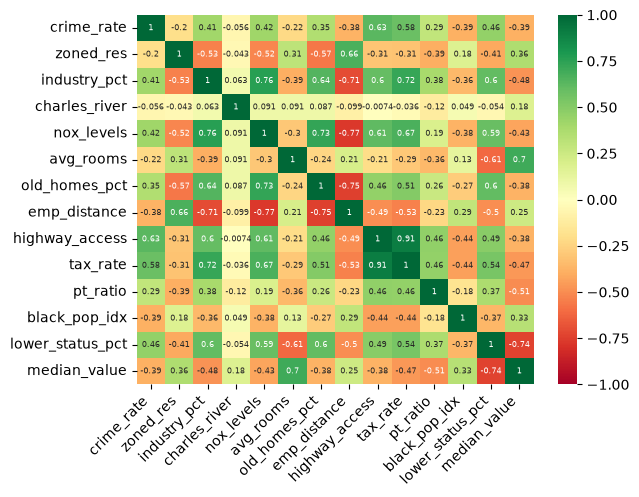

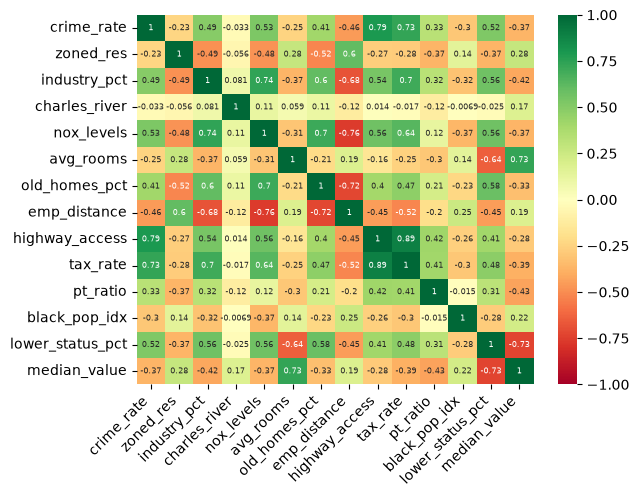

In [400]:
_ = plot_corr_heatmap(lf)
_ = plot_corr_heatmap(no_outlier_lf)

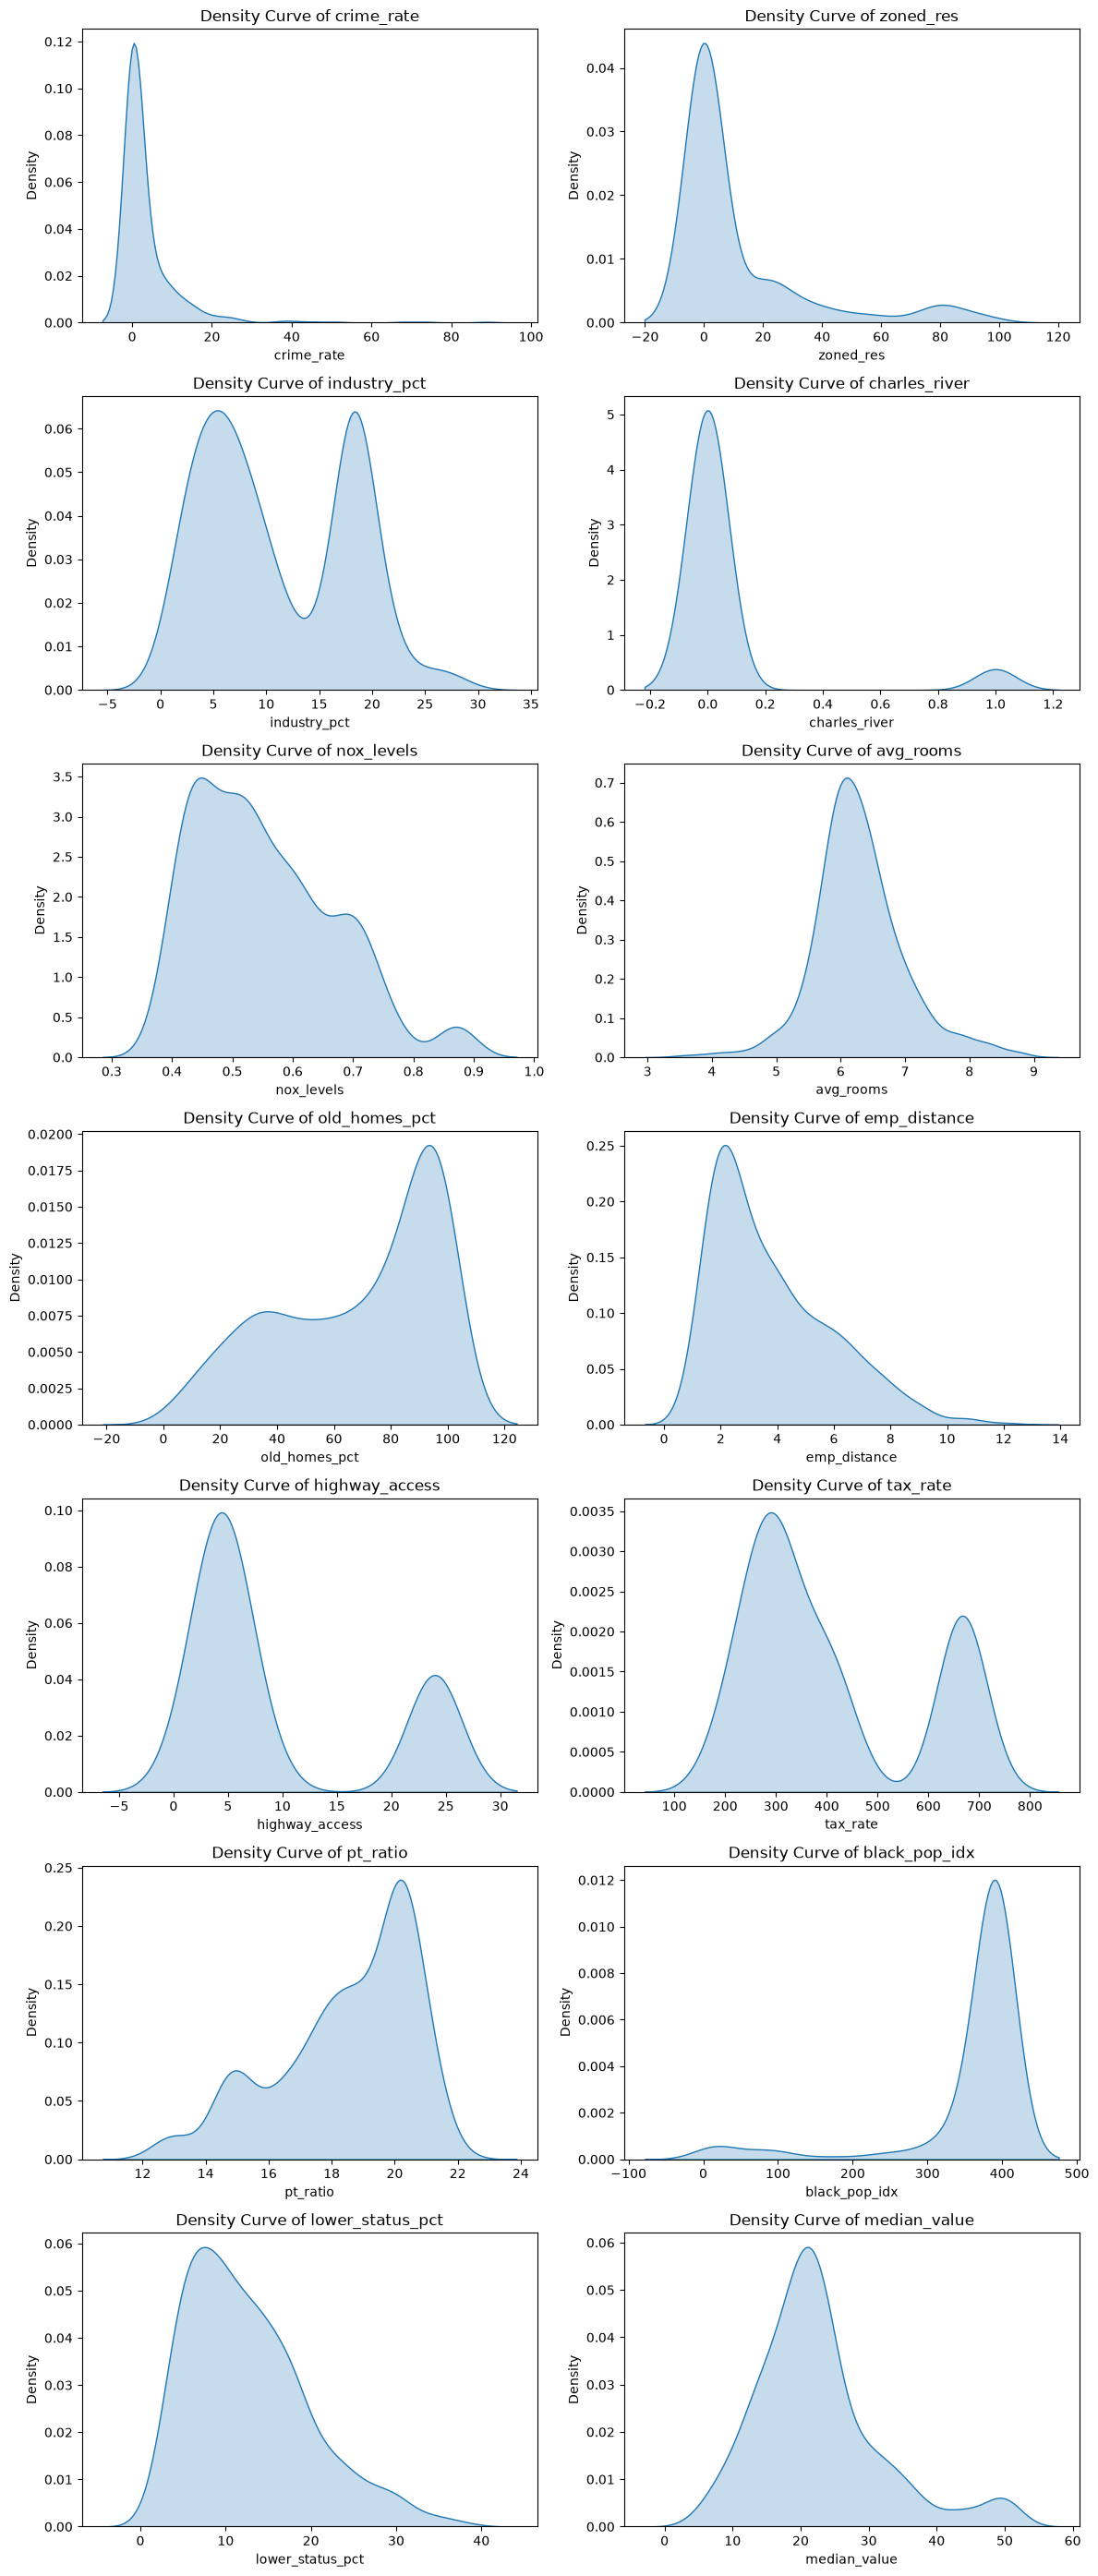

In [401]:
_ = plot_kde(lf)

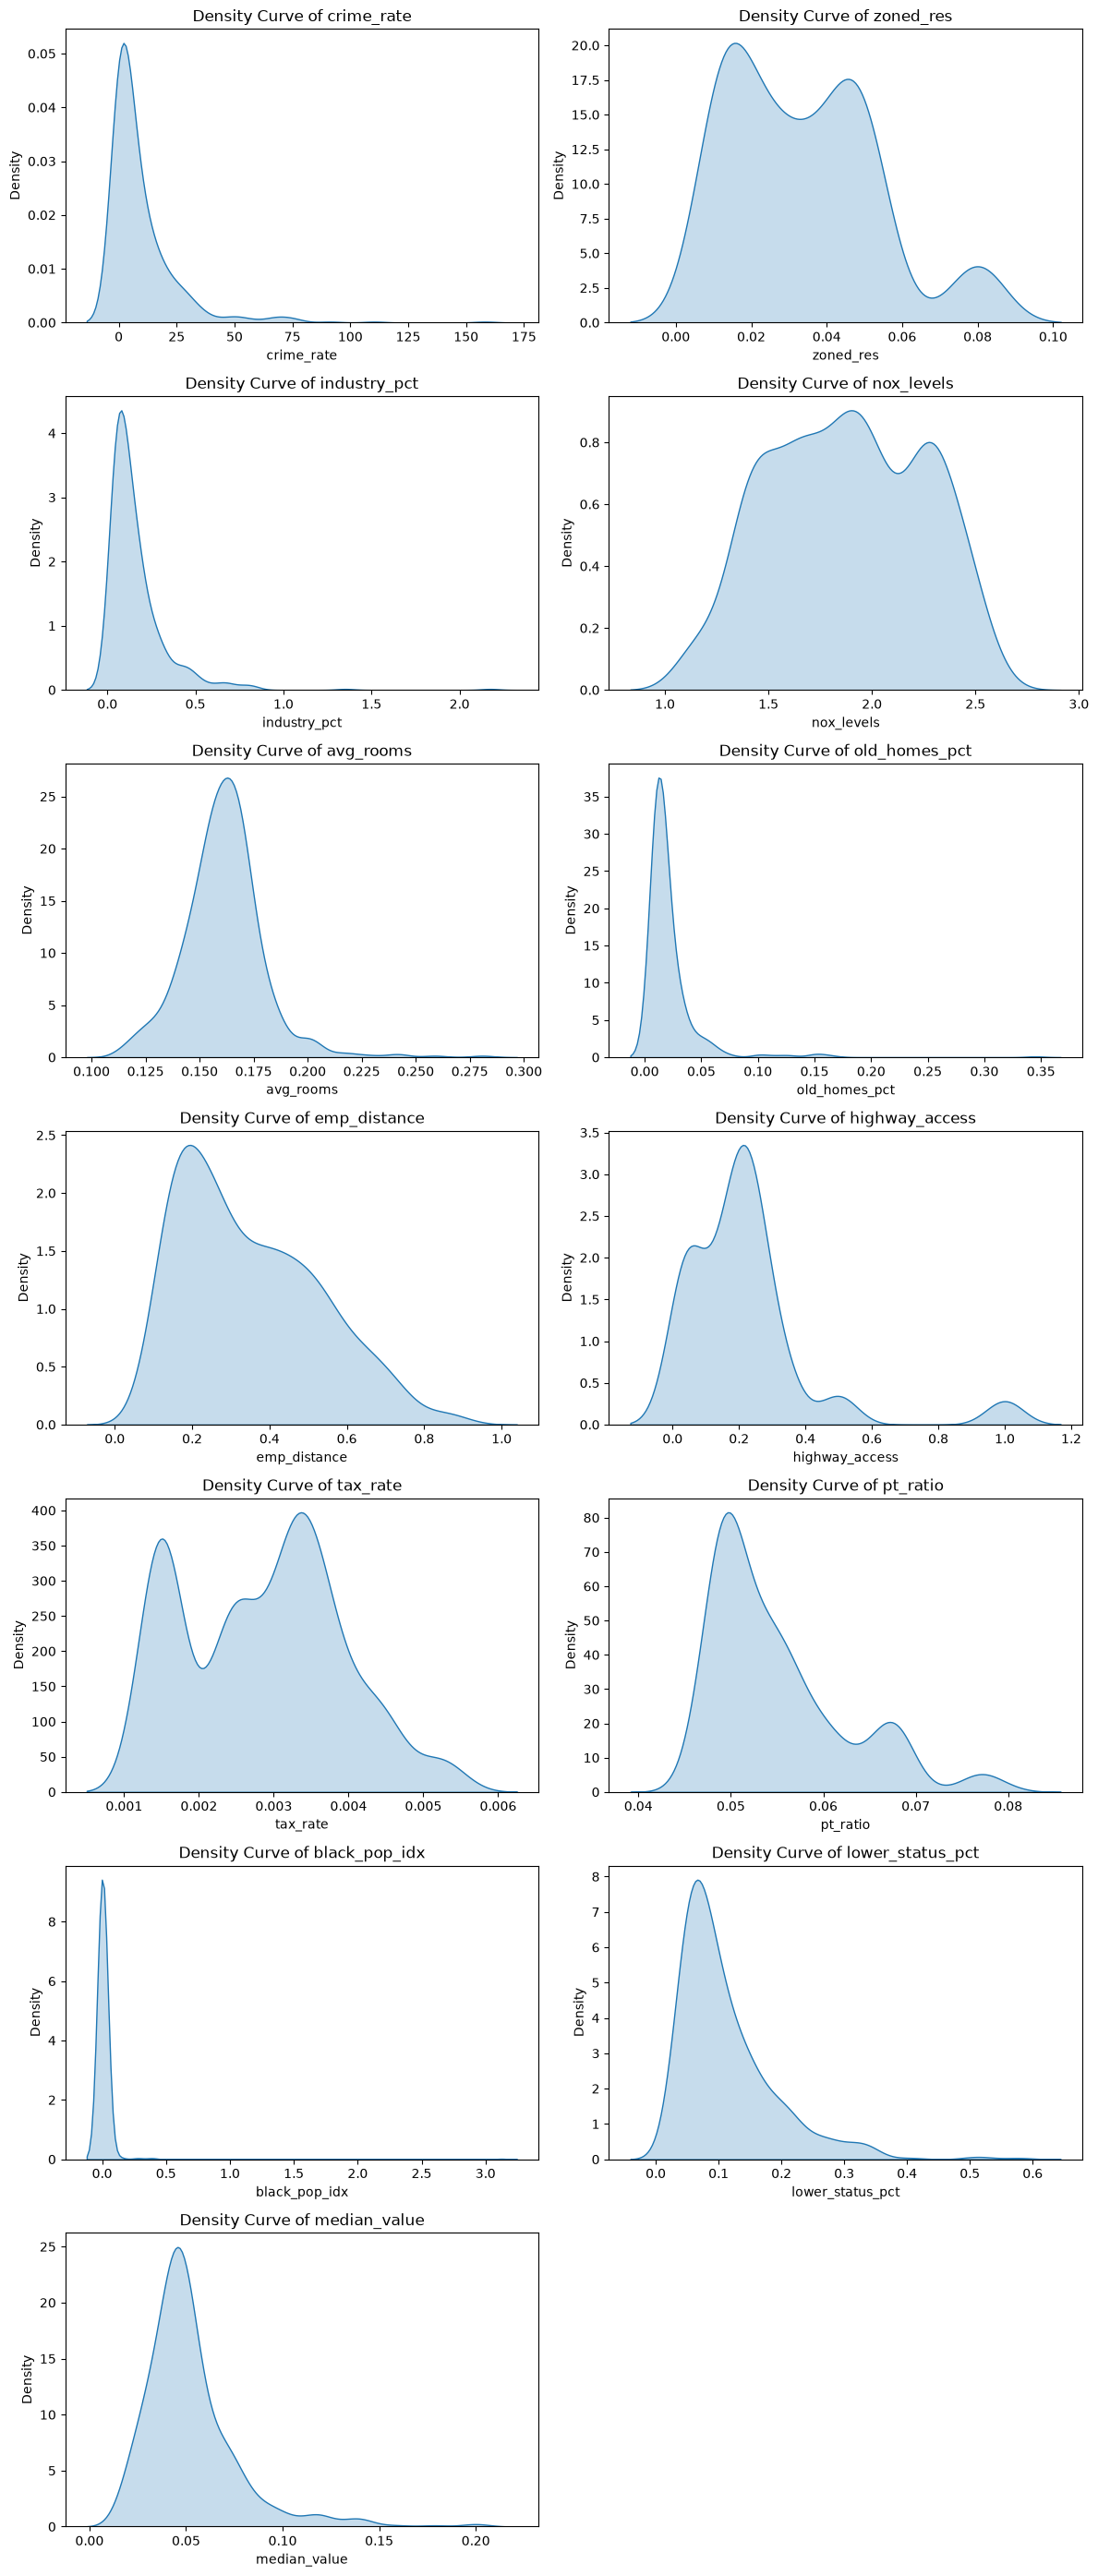

In [402]:
lf_log = lf.select(
    (1 / pl.col(col)).alias(col)
    for col in lf.collect_schema().names()
    if col != "charles_river"
)
_ = plot_kde(lf_log)

In [403]:
from scipy import stats

df = lf.collect()
df_log = lf_log.collect()
print(df.shape)


def _ensure_valid_number(exp: pl.Expr, max_abs: int | float = 1000000) -> pl.Expr:
    return (
        pl.when(exp.is_close(0, abs_tol=0.001))
        .then(pl.lit(0.001))
        .when(exp.is_infinite())
        .then(exp.sign() * max_abs)
        .otherwise(exp)
    )


def _zscore(exp: pl.Expr) -> pl.Expr:
    return (exp - exp.mean()) / exp.std()


for col in df.columns:
    if col == "charles_river":
        continue
    stat = stats.shapiro(df.select(_ensure_valid_number(pl.col(col))))
    stat_log = stats.shapiro(df_log.select(_ensure_valid_number(pl.col(col))))
    print(f"raw: {stat.pvalue=} | normalized: {stat_log.pvalue}")
# lf.collect()

(506, 14)
raw: stat.pvalue=np.float64(1.3285894642242977e-36) | normalized: 4.320464589486402e-32
raw: stat.pvalue=np.float64(7.880837273160896e-34) | normalized: 5.534284894844189e-34
raw: stat.pvalue=np.float64(1.064698570566275e-17) | normalized: 6.186814875923748e-32
raw: stat.pvalue=np.float64(5.776224217453936e-14) | normalized: 7.101599565380751e-09
raw: stat.pvalue=np.float64(2.4119768644268393e-10) | normalized: 1.9574820713111184e-15
raw: stat.pvalue=np.float64(2.2307653882206997e-18) | normalized: 1.029782916156432e-36
raw: stat.pvalue=np.float64(2.18538995236138e-17) | normalized: 3.296721659568774e-13
raw: stat.pvalue=np.float64(8.073212500086387e-30) | normalized: 5.396590391801824e-29
raw: stat.pvalue=np.float64(1.1627807791919998e-23) | normalized: 3.0523364905331387e-15
raw: stat.pvalue=np.float64(2.360649213661593e-17) | normalized: 1.695381709678716e-21
raw: stat.pvalue=np.float64(6.057660246776506e-36) | normalized: 3.0618811492740484e-44
raw: stat.pvalue=np.float64

In [404]:
target = "median_value"
features = list(rename_mapping.values())
features.remove(target)
target, features

('median_value',
 ['crime_rate',
  'zoned_res',
  'industry_pct',
  'charles_river',
  'nox_levels',
  'avg_rooms',
  'old_homes_pct',
  'emp_distance',
  'highway_access',
  'tax_rate',
  'pt_ratio',
  'black_pop_idx',
  'lower_status_pct'])

In [405]:
import statsmodels.api as sm

data = no_outlier_lf.collect()
y = data.get_column(target).to_pandas()
x = data.drop(target).to_pandas()
x = sm.add_constant(x)
model = sm.OLS(y, x)
res = model.fit()
print(res.summary(), res.resid)

                            OLS Regression Results                            
Dep. Variable:           median_value   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     91.36
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          2.90e-115
Time:                        15:16:01   Log-Likelihood:                -1298.1
No. Observations:                 448   AIC:                             2624.
Df Residuals:                     434   BIC:                             2682.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               26.9619      5.689  

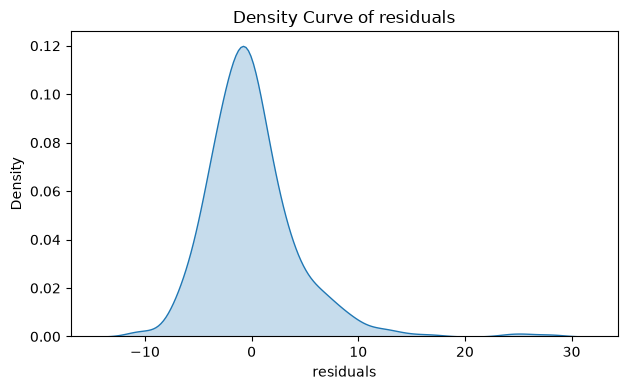

In [406]:
resid_df = pl.DataFrame({"residuals": res.resid})
_ = plot_kde(resid_df)

1.086666772750424


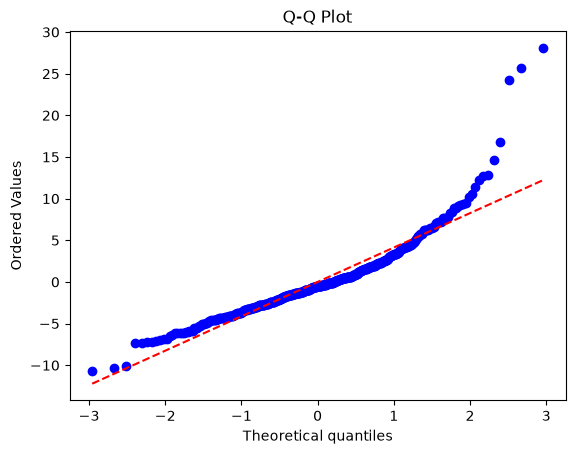

In [407]:
from statsmodels.stats.stattools import durbin_watson

print(durbin_watson(res.resid))
stats.probplot(res.resid, dist="norm", plot=plt)
plt.gca().get_lines()[1].set_linestyle("--")  # 2
plt.title("Q-Q Plot")  # 3
plt.show()

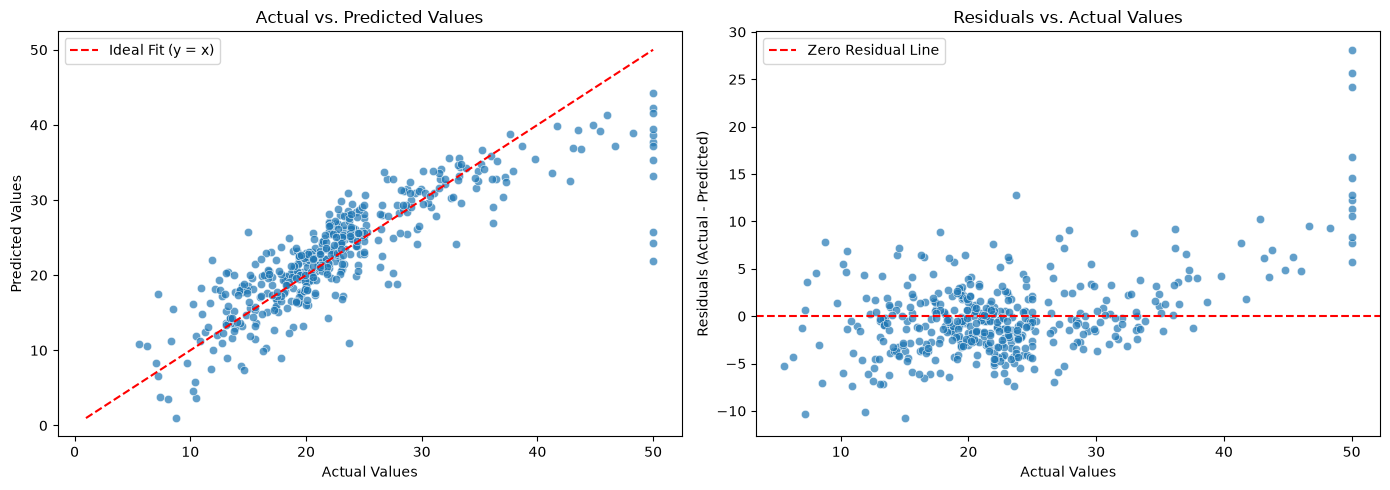

In [408]:
import seaborn as sns

# Calculate fitted (predicted) values and extract residuals
y_pred = res.fittedvalues
residuals = res.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs. Predicted Plot
sns.scatterplot(x=y, y=y_pred, ax=axes[0], alpha=0.7)
# Plot ideal 1:1 prediction line
min_val, max_val = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Ideal Fit (y = x)",
)
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs. Predicted Values")
axes[0].legend()

# 2. Residuals vs. Actual Values Plot
sns.scatterplot(x=y, y=residuals, ax=axes[1], alpha=0.7)
# Plot horizontal zero-residual line
axes[1].axhline(y=0, color="red", linestyle="--", label="Zero Residual Line")
axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Residuals vs. Actual Values")
axes[1].legend()

plt.tight_layout()
plt.show()

In [409]:
data = no_outlier_lf.drop(
    ["zoned_res", "industry_pct", "charles_river", "black_pop_idx"]
).collect()
y = data.get_column(target).to_pandas()
x = data.drop(target).to_pandas()
x = sm.add_constant(x)
model = sm.OLS(y, x)
res = model.fit()
print(res.summary(), res.resid)

                            OLS Regression Results                            
Dep. Variable:           median_value   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     125.8
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          1.71e-115
Time:                        15:16:02   Log-Likelihood:                -1307.4
No. Observations:                 448   AIC:                             2635.
Df Residuals:                     438   BIC:                             2676.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               31.3366      5.394  

In [410]:
import polars as pl
import statsmodels.api as sm


def automated_feature_selection(
    df: pl.DataFrame,
    target_col: str,
    p_value_threshold: float = 0.05,
    corr_threshold: float = 0.70,
) -> list[str]:
    """
    Automated feature selection pipeline:
    1. Fits initial OLS model and drops features with p-value > threshold.
    2. Iteratively checks pairwise correlations between remaining features.
    3. If correlation > corr_threshold, drops the feature with lower correlation to target.
    """
    # Extract features and target
    features = [col for col in df.columns if col != target_col]
    X_df = df.select(features).to_pandas()
    y = df.get_column(target_col).to_pandas()

    # -------------------------------------------------------------
    # Step 1: Fit full model & drop features with p-value > 0.05
    # -------------------------------------------------------------
    X_const = sm.add_constant(X_df)
    model = sm.OLS(y, X_const).fit()

    # Extract p-values (excluding intercept 'const')
    p_values = model.pvalues.drop("const", errors="ignore")
    significant_features = p_values[p_values <= p_value_threshold].index.tolist()

    print(
        f"Step 1 Complete: Kept {len(significant_features)}/{len(features)} features with p <= {p_value_threshold}"
    )
    print(f"Dropped due to high p-value: {set(features) - set(significant_features)}\n")

    # If no features survive, exit early
    if not significant_features:
        return []

    # -------------------------------------------------------------
    # Step 2: Remove collinear features (drop lower target correlation)
    # -------------------------------------------------------------
    # Calculate correlations among surviving features and against target
    surviving_df = df.select(significant_features + [target_col]).to_pandas()
    corr_matrix = surviving_df.corr().abs()
    target_corrs = corr_matrix[target_col].drop(target_col)

    current_features = significant_features.copy()
    dropped_for_collinearity = []

    # Loop through pairs to find correlations higher than threshold
    for i in range(len(significant_features)):
        f1 = significant_features[i]
        if f1 not in current_features:
            continue

        for j in range(i + 1, len(significant_features)):
            f2 = significant_features[j]
            if f2 not in current_features:
                continue

            # Check pairwise correlation between feature 1 and feature 2
            if corr_matrix.loc[f1, f2] >= corr_threshold:
                # Compare their correlation with the target variable
                r1 = target_corrs[f1]
                r2 = target_corrs[f2]

                # Drop the one with weaker correlation to target
                to_drop = f2 if r1 >= r2 else f1
                current_features.remove(to_drop)
                dropped_for_collinearity.append(
                    (to_drop, f1 if to_drop == f2 else f2, corr_matrix.loc[f1, f2])
                )

                if to_drop == f1:
                    break  # Stop checking f1 if it was dropped

    print(f"Step 2 Complete: Kept {len(current_features)} non-collinear features.")
    for dropped, kept_because, r_val in dropped_for_collinearity:
        print(
            f"Dropped '{dropped}' due to high correlation ({r_val:.2f}) with '{kept_because}'"
        )

    return current_features


# --- Execution Example ---
selected_features = automated_feature_selection(
    df=data, target_col="median_value", p_value_threshold=0.05, corr_threshold=0.70
)

x = no_outlier_lf.select(selected_features).drop("nox_levels").collect().to_pandas()
y = no_outlier_lf.select("median_value").collect().to_pandas()
x = sm.add_constant(x)
res = sm.OLS(y, x).fit()
print(res.summary())

Step 1 Complete: Kept 8/9 features with p <= 0.05
Dropped due to high p-value: {'old_homes_pct'}

Step 2 Complete: Kept 5 non-collinear features.
Dropped 'highway_access' due to high correlation (0.79) with 'crime_rate'
Dropped 'crime_rate' due to high correlation (0.73) with 'tax_rate'
Dropped 'emp_distance' due to high correlation (0.76) with 'nox_levels'
                            OLS Regression Results                            
Dep. Variable:           median_value   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     235.7
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          3.05e-108
Time:                        15:16:02   Log-Likelihood:                -1337.9
No. Observations:                 448   AIC:                             2686.
Df Residuals:                     443   BIC:                             2706.
Df Model

# BTC

In [411]:
import polars as pl

path = "/Users/zipp/Desktop/programming/ml-training/data/bitcoin_dataset.csv"
lf = pl.scan_csv(path, infer_schema_length=2908)
lf = (
    lf.sort(by="Date", descending=False)
    .rename(lambda s: s.lower())
    .select(pl.col("date").str.to_datetime(r"%m/%d/%Y %H:%M"), "btc_market_price")
)
lf.describe()

statistic,date,btc_market_price
str,str,f64
"""count""","""2906""",2906.0
"""null_count""","""0""",0.0
"""mean""","""2014-02-08 12:00:00""",839.104218
"""std""",null,2304.972497
"""min""","""2010-02-17 00:00:00""",0.0
"""25%""","""2012-02-13 00:00:00""",6.65062
"""50%""","""2014-02-09 00:00:00""",235.13
"""75%""","""2016-02-05 00:00:00""",594.274886
"""max""","""2018-01-31 00:00:00""",19498.68333


<Axes: ylabel='Density'>

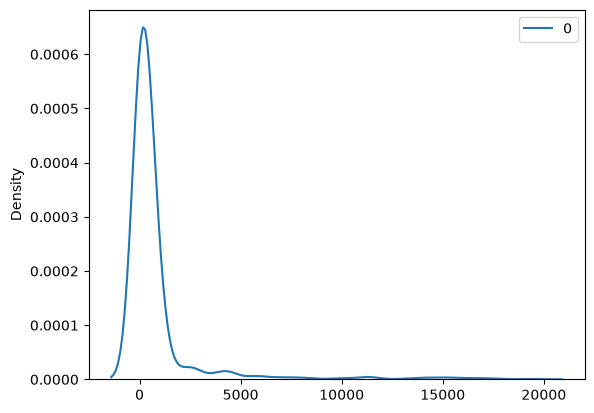

In [412]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(lf.select("btc_market_price").collect())

<Axes: ylabel='Density'>

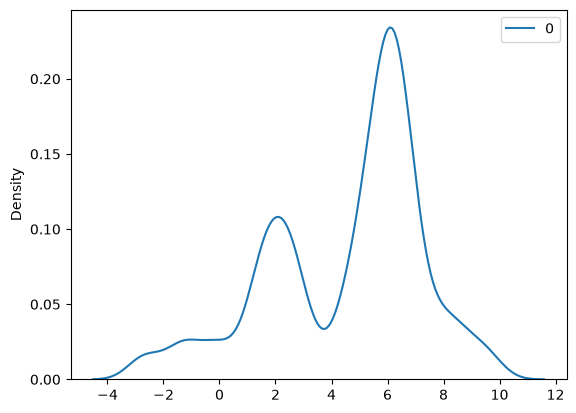

In [413]:
lf_log = lf.with_columns(pl.col("btc_market_price").log())
sns.kdeplot(lf_log.select("btc_market_price").collect())

<Axes: xlabel='date', ylabel='btc_market_price'>

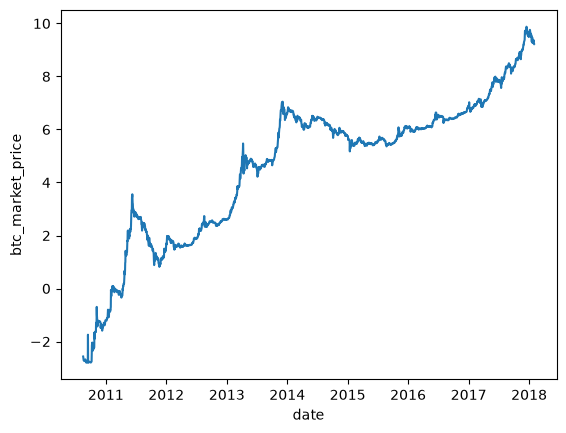

In [414]:
sns.lineplot(lf_log.collect().to_pandas(), x="date", y="btc_market_price")

In [415]:
import statsmodels.api as sm

size = 1000
x = (
    lf_log.head(size)
    .select((pl.col("date") - pl.col("date").min()).dt.total_days())
    .collect()
    .get_column("date")
    .to_numpy()
)
# x = sm.add_constant(x)
y = (
    lf_log.head(size)
    .select("btc_market_price")
    .collect()
    .get_column("btc_market_price")
    .to_numpy()
)
ols = sm.OLS(y, x)
res = ols.fit()
print(res.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.958
Model:                            OLS   Adj. R-squared (uncentered):              0.958
Method:                 Least Squares   F-statistic:                          2.279e+04
Date:                Mon, 28 Sep 2026   Prob (F-statistic):                        0.00
Time:                        15:16:02   Log-Likelihood:                         -1542.9
No. Observations:                1000   AIC:                                      3088.
Df Residuals:                     999   BIC:                                      3093.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

<Axes: ylabel='Density'>

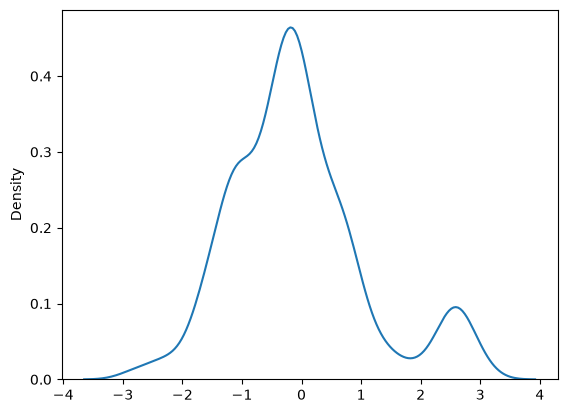

In [416]:
sns.kdeplot(res.resid)

<Axes: >

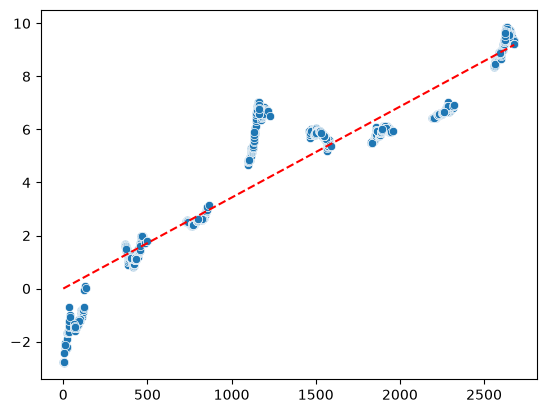

In [417]:
sns.lineplot(x=x, y=res.fittedvalues, color="red", linestyle="--")
sns.scatterplot(x=x, y=y)

ShapiroResult(statistic=np.float64(0.944538543815798), pvalue=np.float64(6.657965764925539e-19))


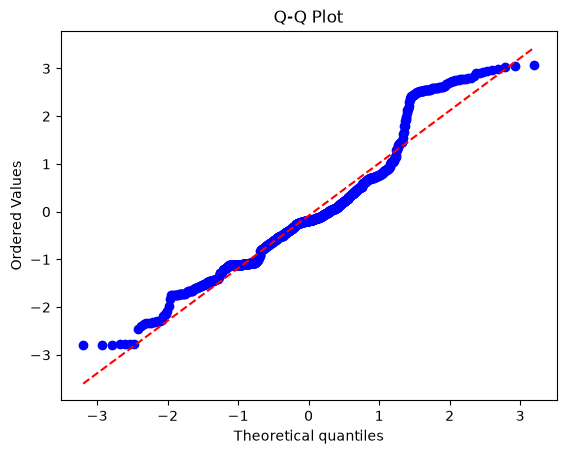

In [418]:
stats.probplot(res.resid, dist="norm", plot=plt)
print(stats.shapiro(res.resid))
plt.gca().get_lines()[1].set_linestyle("--")  # 2
plt.title("Q-Q Plot")  # 3
plt.show()

In [419]:
from statsmodels.tsa.arima.model import ARIMA

sarima = ARIMA(y, order=(1, 0, 0))
res = sarima.fit()

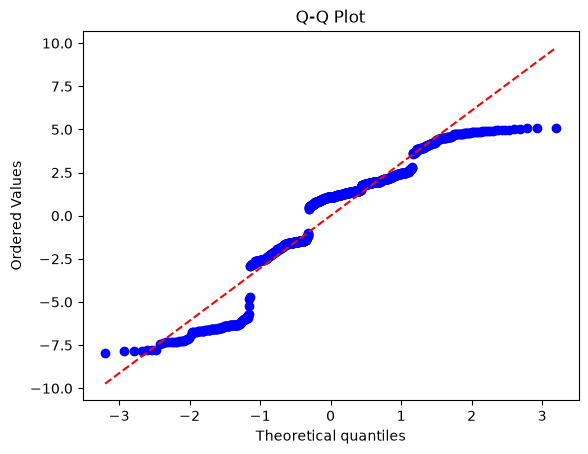

In [420]:
stats.probplot(res.resid, dist="norm", plot=plt)
plt.gca().get_lines()[1].set_linestyle("--")  # 2
plt.title("Q-Q Plot")  # 3
plt.show()